In [1]:
# Plotting country level PM2.5 mortality difference between two scenarios, ensemble mean, final 10 years
# Log scale which starts at zero

In [2]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import get_scenario_config
from utils.utils import autosize_figure, land_filter, create_global_country_map

In [8]:
def process_mortality_for_plotting(model, scenario, config):
    """
    Calculate final decade and ensemble mean
    """
    # Set-up
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/pm25/gridpoint_mortality/"
    years = config["years"]
    dates = f"{years.start}-{years.stop}"

    # Load file
    file = f"Mortality_Country_sum_{model}_{scenario}_{dates}.nc"
    file_path = os.path.join(MORT_DIR, file)
    da = xr.open_dataarray(file_path)

    # Calculate end of scenario mean (10 years)
    end_idx = da.sizes["year"]
    # Select the last 10 years
    da_last10 = da.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last time values
    start_time = da_last10.year[0].item()
    end_time = da_last10.year[-1].item()

    # Calculate ensemble and temporal mean
    da_mean = da_last10.mean(dim=("ensemble", "year"))
    return da_mean, start_time, end_time

In [4]:
def plot_difference_country_level_mortality(da, model, scenario_diff, start_year, end_year, levels, SAVE_DIR):
    # Create figure
    fig = plt.figure(figsize=autosize_figure(1, 1))
    gs = GridSpec(2, 1, height_ratios=[15, 1])  # rows, columns

    # Map projection and display
    projection = ccrs.Robinson()
    crs = ccrs.PlateCarree()

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none')

    # First panel
    ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
    cb = land_filter(da).plot(
        transform=crs,
        levels=levels,
        add_colorbar=False,
        subplot_kws={'projection': projection}
    )
    ax.coastlines(resolution="50m", linewidth=0.75)
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"Mortality due to PM2.5\n {model} {scenario_diff} {start_year}-{end_year}", fontsize=16)

    # First colorbar
    cax = fig.add_subplot(gs[1, 0])
    col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
    col_bar.set_label("Mortality (year$^{-1}$)", fontsize=13)

    plt.tight_layout()

    out_file = f"Mortality_country_{model}_{scenario_diff}_{start_year}-{end_year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

Years are the same


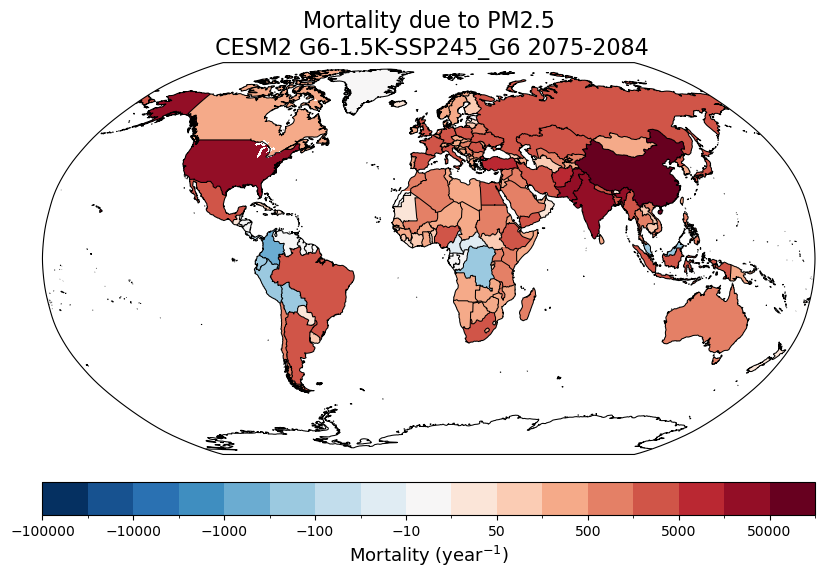

In [7]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/pm25/Country_level/"

model = "CESM2"

# Set up scenario 1 and 2 so that difference = s1 - s2
scenario1 = "G6-1.5K"
scenario2 = "SSP245_G6"

scenario_name = f"{scenario1}-{scenario2}"

config1 = get_scenario_config(model, scenario1)
config2 = get_scenario_config(model, scenario2)

da1, first_year1, last_year1 = process_mortality_for_plotting(model, scenario1, config1)
da2, first_year2, last_year2 = process_mortality_for_plotting(model, scenario2, config2)

if first_year1 == first_year2 and last_year1 == last_year2:
    print("Years are the same")

da = da1 - da2  # Check this is the way round you want it

# Convert country level to a global map with lat/lon
da_global = create_global_country_map(da)

# Assign levels for colorbar (this may take adjustment depending on comparison plots)
levels = [-100000, -50000, -10000, -5000, -1000, -500, -100, -50, -10, 10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]

# Plotting without ocean
plot_difference_country_level_mortality(da_global, model, scenario_name, first_year1, last_year1, levels, SAVE_DIR)